# 🖼️ Dataset 4: Natural Images — EfficientNetB0 + Grad-CAM
## Kỹ thuật: EfficientNet Transfer Learning + Grad-CAM Explainability

**Pipeline:** Dataset Analysis → Samples → Build EfficientNetB0 → Train → Confusion Matrix → Grad-CAM

---

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import matplotlib.cm as cm_plt
import seaborn as sns
import numpy as np
import cv2
import os
import random

SEED = 42

os.environ['PYTHONHASHSEED'] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# TensorFlow deterministic ops
tf.keras.utils.set_random_seed(SEED)
tf.config.experimental.enable_op_determinism()

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.titlesize': 12, 'axes.titleweight': 'bold'})

DATA_DIR = '../data/natural_images/natural_images'
SAVE_DIR = '../results/natural_images'
os.makedirs(SAVE_DIR, exist_ok=True)

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
EPOCHS     = 8

print(f'TF: {tf.__version__}')
print(f'Random Seed: {SEED}')

2026-05-09 19:43:24.578333: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-09 19:43:24.605839: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-09 19:43:25.055313: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


TF: 2.13.0
Random Seed: 42


## 📊 1. Dataset Analysis

In [2]:
classes = sorted([d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))])
class_counts = {c: len(os.listdir(os.path.join(DATA_DIR, c))) for c in classes}

print(f'Classes ({len(classes)}): {classes}')
for c, n in class_counts.items():
    print(f'  {c:12s}: {n:,} images')
print(f'  Total      : {sum(class_counts.values()):,}')

Classes (8): ['airplane', 'car', 'cat', 'dog', 'flower', 'fruit', 'motorbike', 'person']
  airplane    : 727 images
  car         : 968 images
  cat         : 885 images
  dog         : 702 images
  flower      : 843 images
  fruit       : 1,000 images
  motorbike   : 788 images
  person      : 986 images
  Total      : 6,899


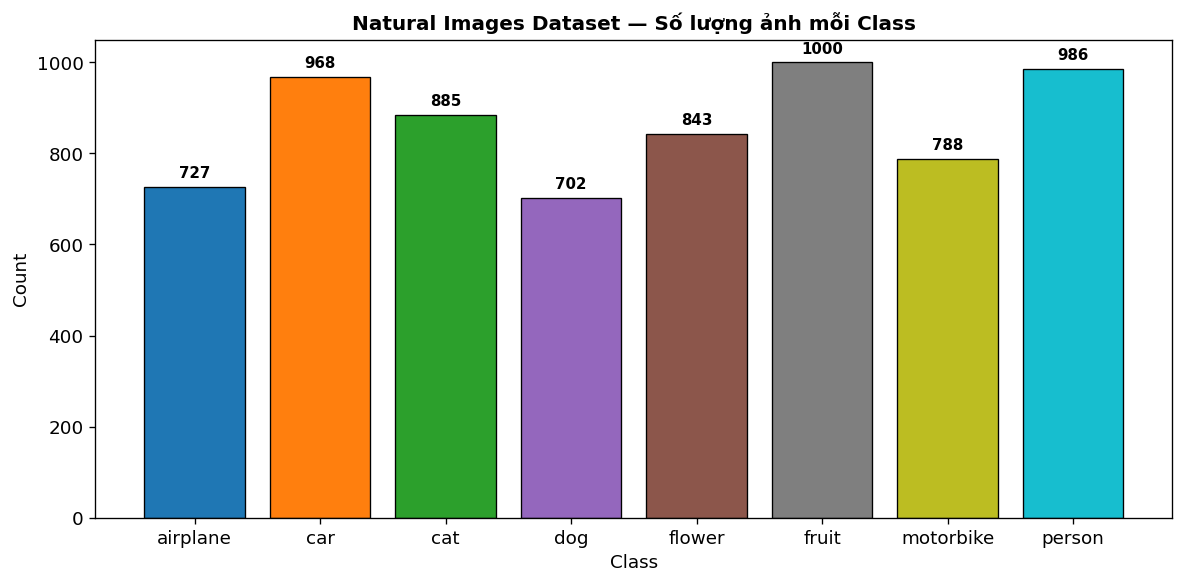

In [3]:
# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
colors = plt.cm.tab10(np.linspace(0, 1, len(classes)))
bars = ax.bar(class_counts.keys(), class_counts.values(),
              color=colors, edgecolor='black', linewidth=0.8)
ax.set_title('Natural Images Dataset — Số lượng ảnh mỗi Class')
ax.set_ylabel('Count')
ax.set_xlabel('Class')
for bar, val in zip(bars, class_counts.values()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+20,
            f'{val}', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/01_class_distribution.png', bbox_inches='tight')
plt.show()

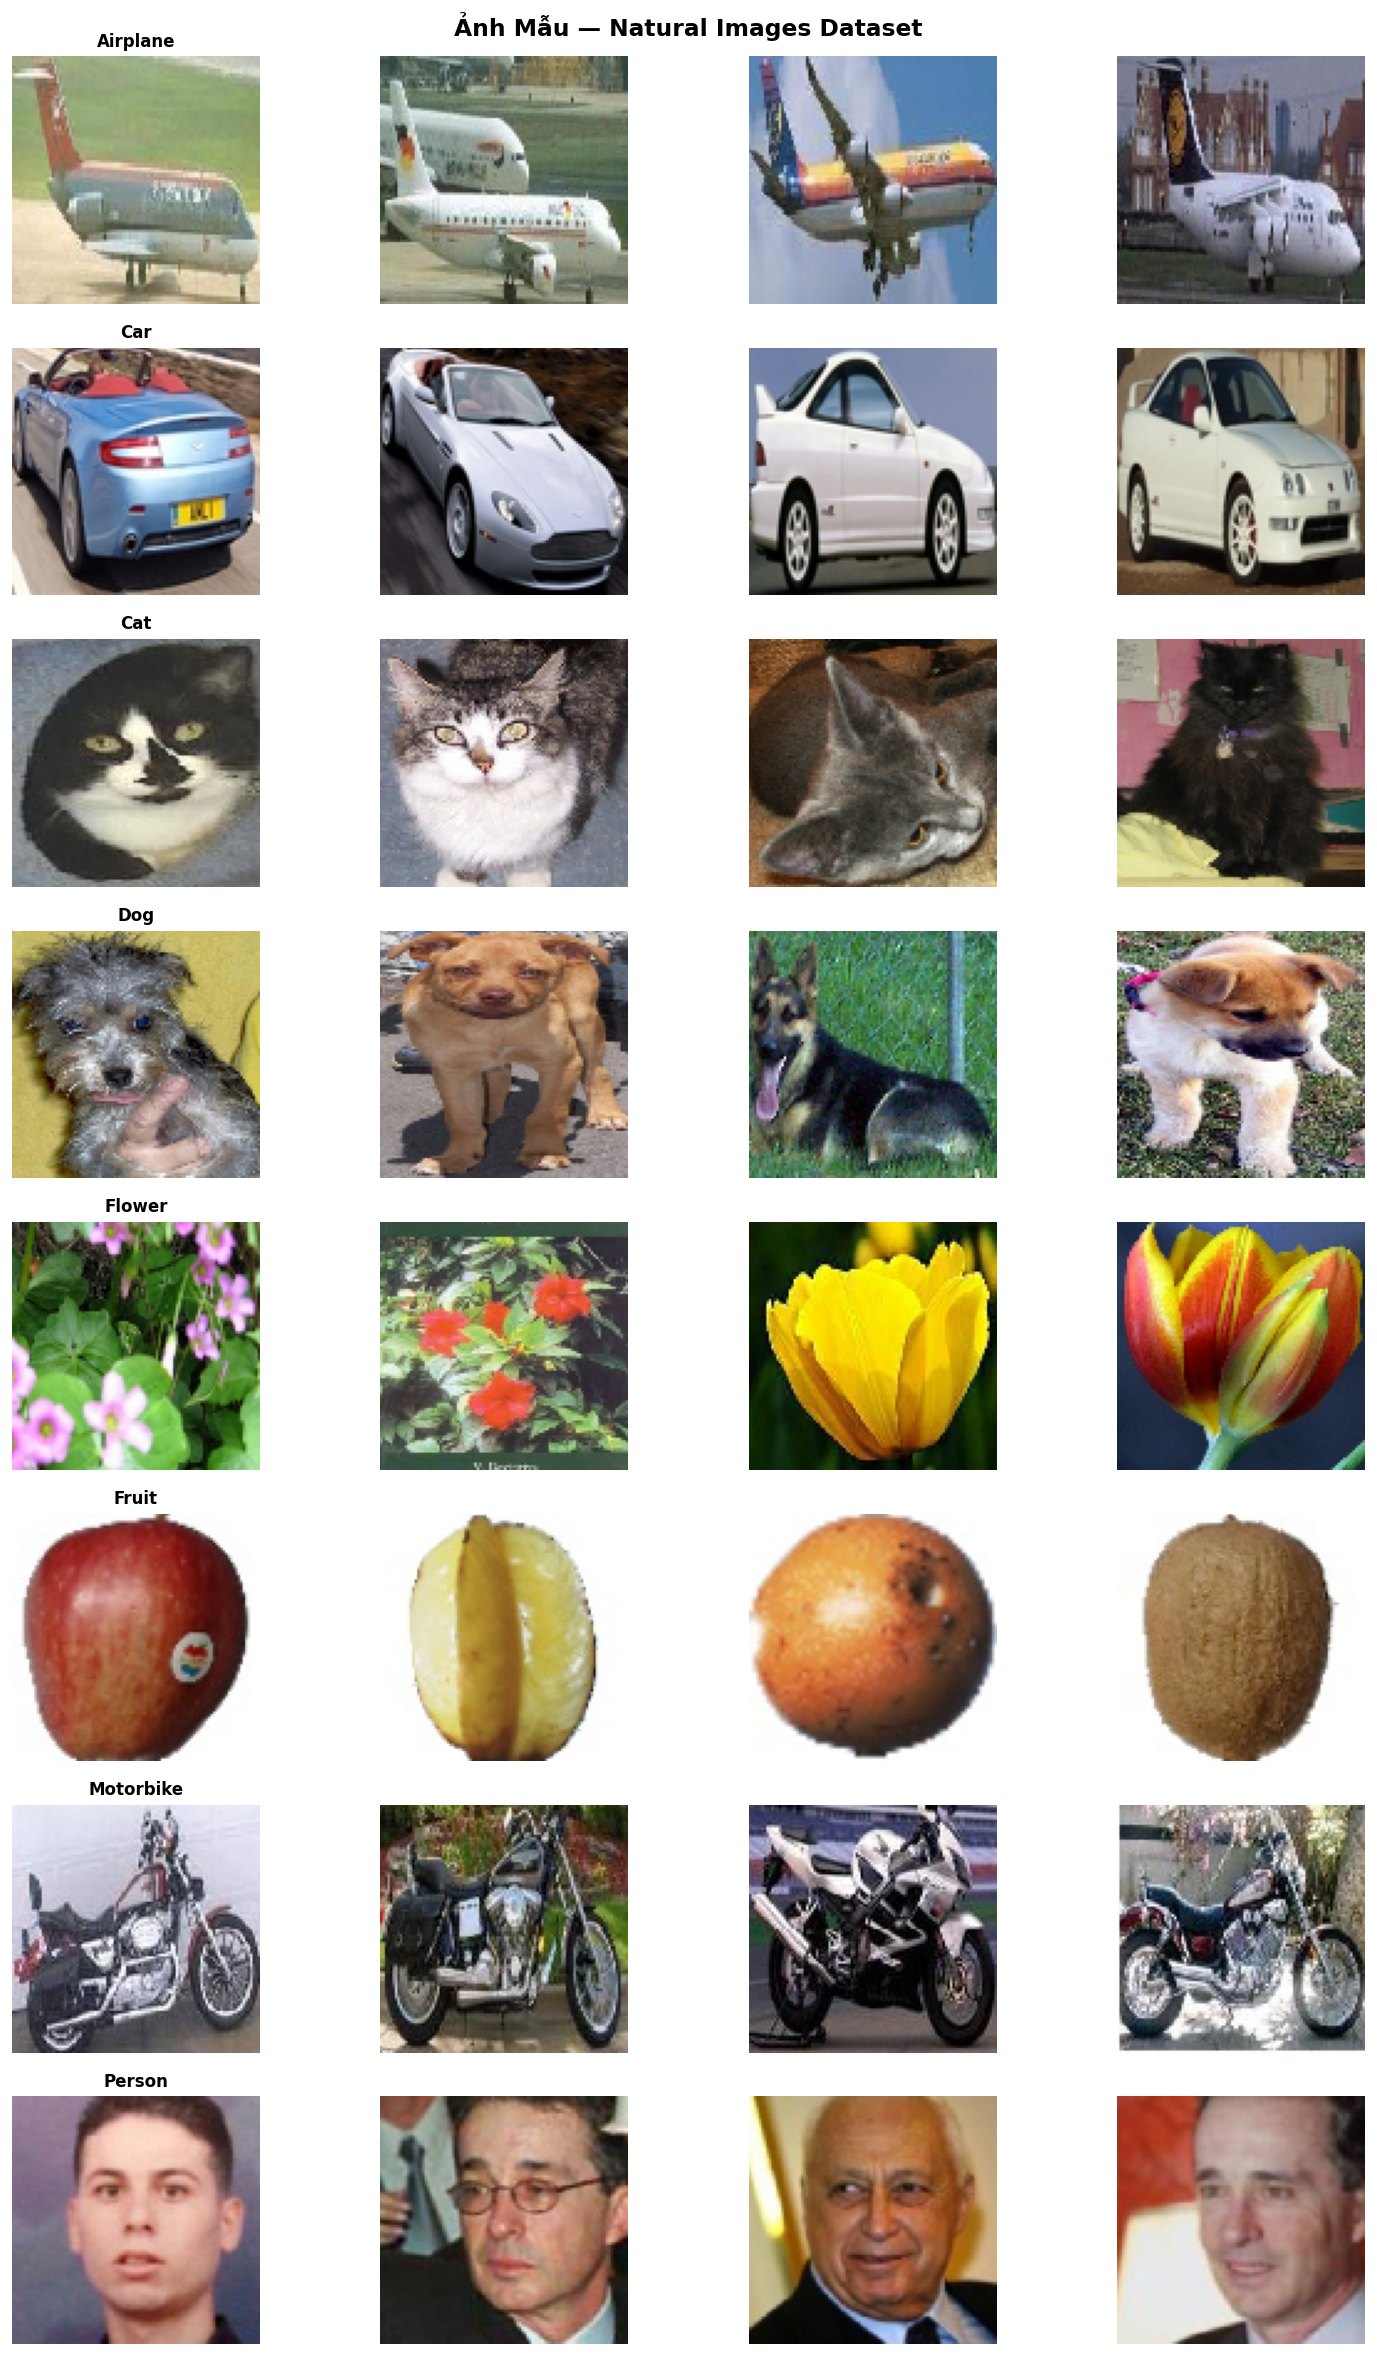

In [4]:
# Sample images grid
cols = 4
rows = len(classes)
fig, axes = plt.subplots(rows, cols, figsize=(13, rows*2.5))

for r, cls in enumerate(classes):
    cls_dir = os.path.join(DATA_DIR, cls)
    img_files = [f for f in os.listdir(cls_dir) if f.lower().endswith(('.jpg','.jpeg','.png'))][:cols]
    for c, fname in enumerate(img_files):
        img = load_img(os.path.join(cls_dir, fname), target_size=(100, 100))
        axes[r, c].imshow(img)
        axes[r, c].axis('off')
        if c == 0:
            axes[r, c].set_title(cls.capitalize(), fontweight='bold', fontsize=10)

plt.suptitle('Ảnh Mẫu — Natural Images Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/02_sample_images.png', bbox_inches='tight')
plt.show()

## 🏗️ 2. Build EfficientNetB0

In [5]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=25,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='reflect'
)
train_gen = datagen.flow_from_directory(
    DATA_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training', shuffle=True,
    seed=SEED)
val_gen = datagen.flow_from_directory(
    DATA_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation', shuffle=False,
    seed=SEED)

NUM_CLASSES = len(classes)
print(f'Train: {train_gen.samples}, Val: {val_gen.samples}')

Found 5522 images belonging to 8 classes.
Found 1377 images belonging to 8 classes.
Train: 5522, Val: 1377


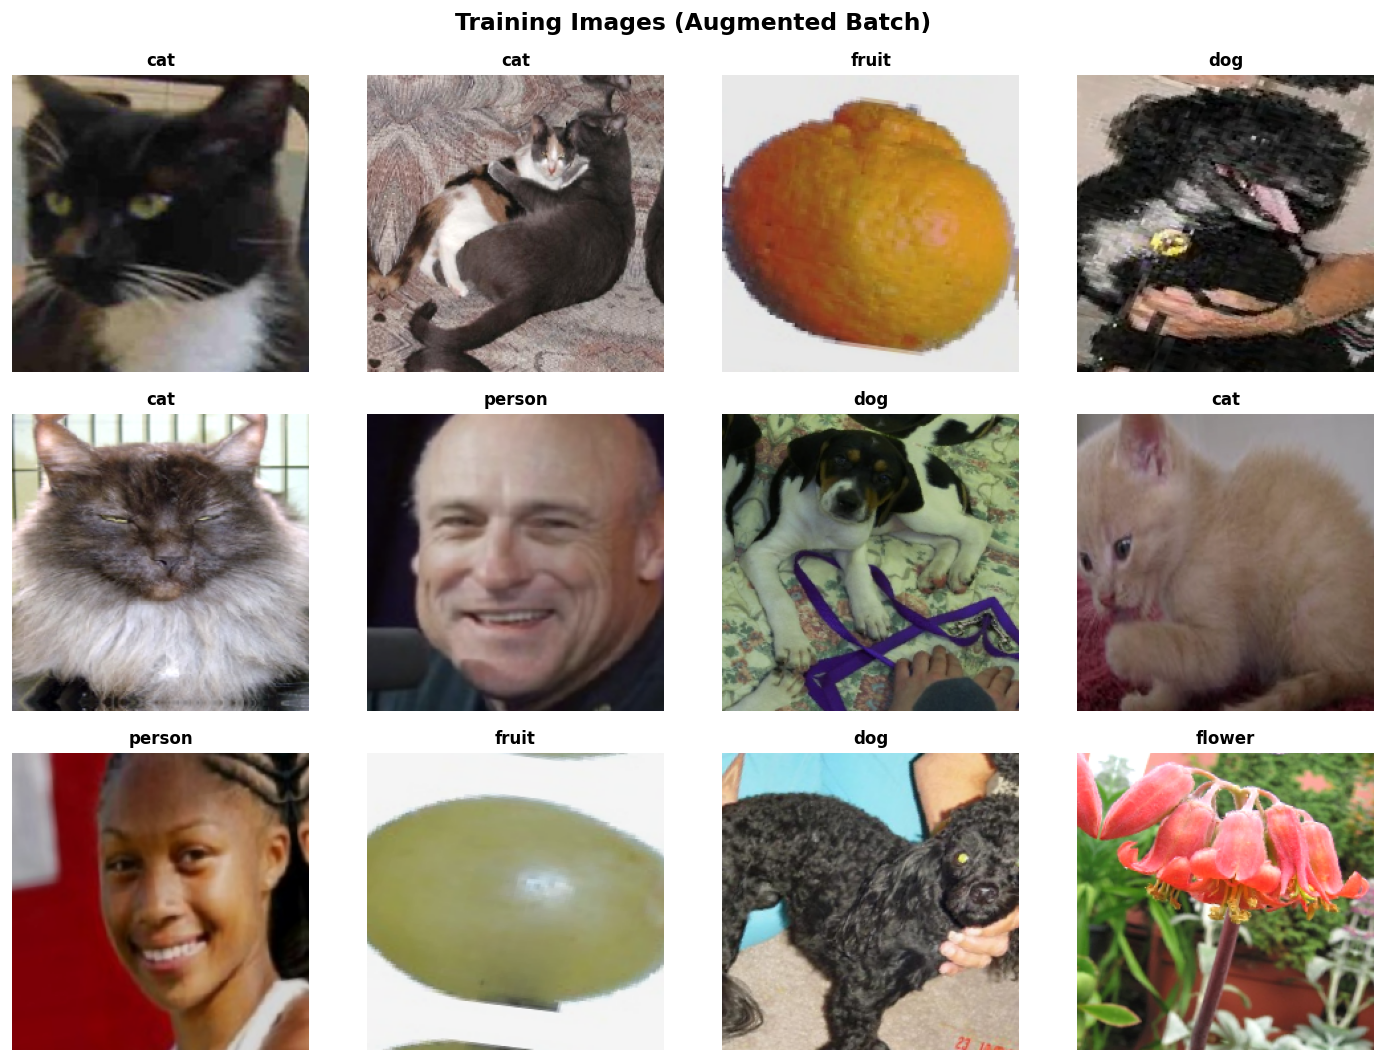

In [6]:
# Visualize training images
x_batch, y_batch = next(train_gen)

fig, axes = plt.subplots(3, 4, figsize=(12, 9))
axes = axes.flatten()

for i, ax in enumerate(axes):
    img = x_batch[i]
    label = classes[np.argmax(y_batch[i])]

    ax.imshow(img)
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.axis('off')

plt.suptitle('Training Images (Augmented Batch)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/train_batch_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

In [7]:
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_model.trainable = False

inputs = tf.keras.Input(shape=(224,224,3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
model = tf.keras.Model(inputs, outputs, name='EfficientNetB0_Natural')

model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

print(f'Total params: {model.count_params():,}')
trainable_p = sum(tf.keras.backend.count_params(w) for w in model.trainable_weights)
print(f'Trainable: {trainable_p:,}')

2026-05-09 19:43:29.983113: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-05-09 19:43:29.984141: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-05-09 19:43:29.986755: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

Total params: 4,384,683
Trainable: 332,552


## 🚀 3. Training

In [8]:
history = model.fit(
    train_gen, epochs=EPOCHS, validation_data=val_gen,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True, monitor='val_accuracy'),
        tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=2, min_lr=1e-7, verbose=1)
    ],
    verbose=1
)

Epoch 1/8
 15/173 [=>............................] - ETA: 42s - loss: 1.7987 - accuracy: 0.3498

173/173 [==============================] - 62s 346ms/step - loss: 1.3112 - accuracy: 0.5138 - val_loss: 2.5228 - val_accuracy: 0.2186 - lr: 0.0010
Epoch 2/8
173/173 [==============================] - 58s 338ms/step - loss: 1.0519 - accuracy: 0.6146 - val_loss: 1.8846 - val_accuracy: 0.2447 - lr: 0.0010
Epoch 3/8
173/173 [==============================] - 59s 339ms/step - loss: 0.9668 - accuracy: 0.6449 - val_loss: 1.3927 - val_accuracy: 0.4720 - lr: 0.0010
Epoch 4/8
173/173 [==============================] - 59s 342ms/step - loss: 0.9104 - accuracy: 0.6661 - val_loss: 0.9503 - val_accuracy: 0.6776 - lr: 0.0010
Epoch 5/8
173/173 [==============================] - 58s 337ms/step - loss: 0.8635 - accuracy: 0.6818 - val_loss: 0.9383 - val_accuracy: 0.6492 - lr: 0.0010
Epoch 6/8
173/173 [==============================] - 58s 336ms/step - loss: 0.8160 - accuracy: 0.7079 - val_loss: 0.8936 - val_accuracy: 0.6957 - lr: 0.0010
Epoch 7/8
173/173 [==============================] - 58s 337ms/step 

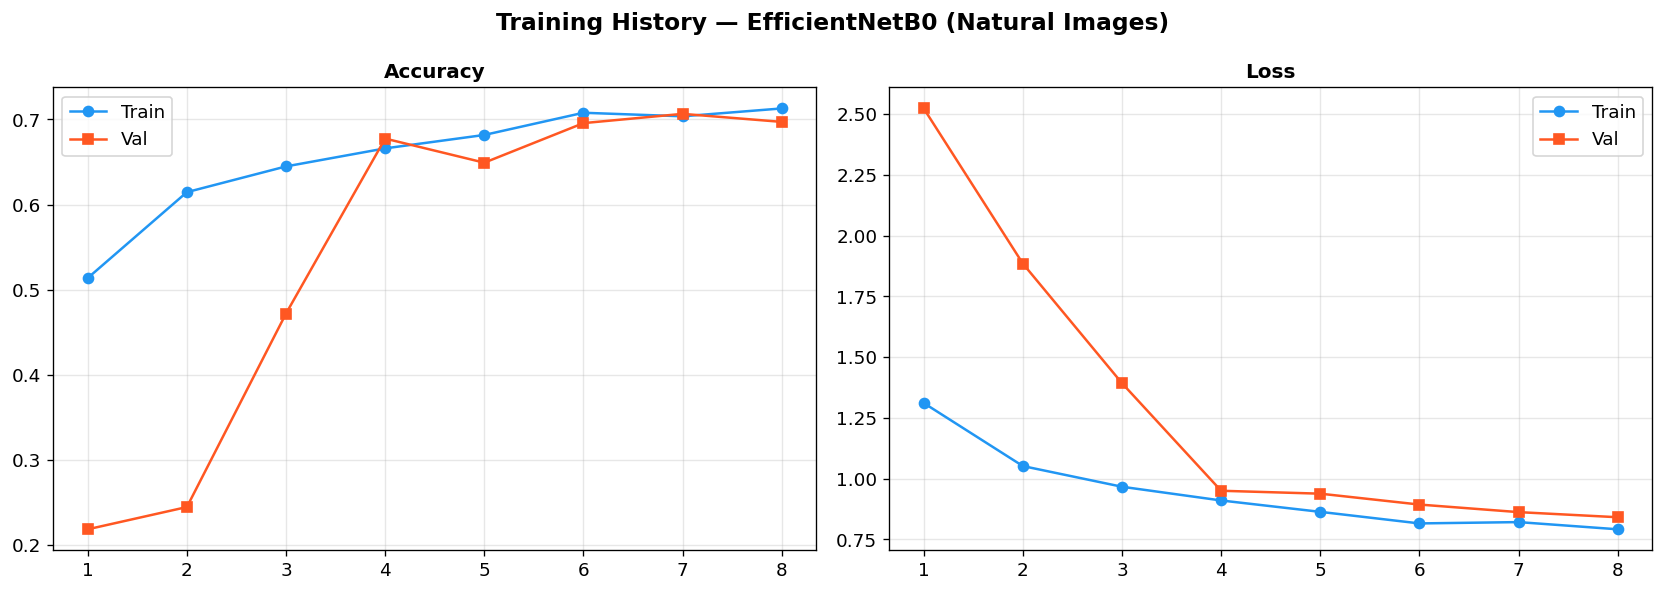

Best val accuracy: 0.7066


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
eps = range(1, len(history.history['accuracy'])+1)

axes[0].plot(eps, history.history['accuracy'],     'o-', color='#2196F3', label='Train')
axes[0].plot(eps, history.history['val_accuracy'], 's-', color='#FF5722', label='Val')
axes[0].set_title('Accuracy')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(eps, history.history['loss'],     'o-', color='#2196F3', label='Train')
axes[1].plot(eps, history.history['val_loss'], 's-', color='#FF5722', label='Val')
axes[1].set_title('Loss')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Training History — EfficientNetB0 (Natural Images)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/03_training_history.png', bbox_inches='tight')
plt.show()
print(f'Best val accuracy: {max(history.history["val_accuracy"]):.4f}')

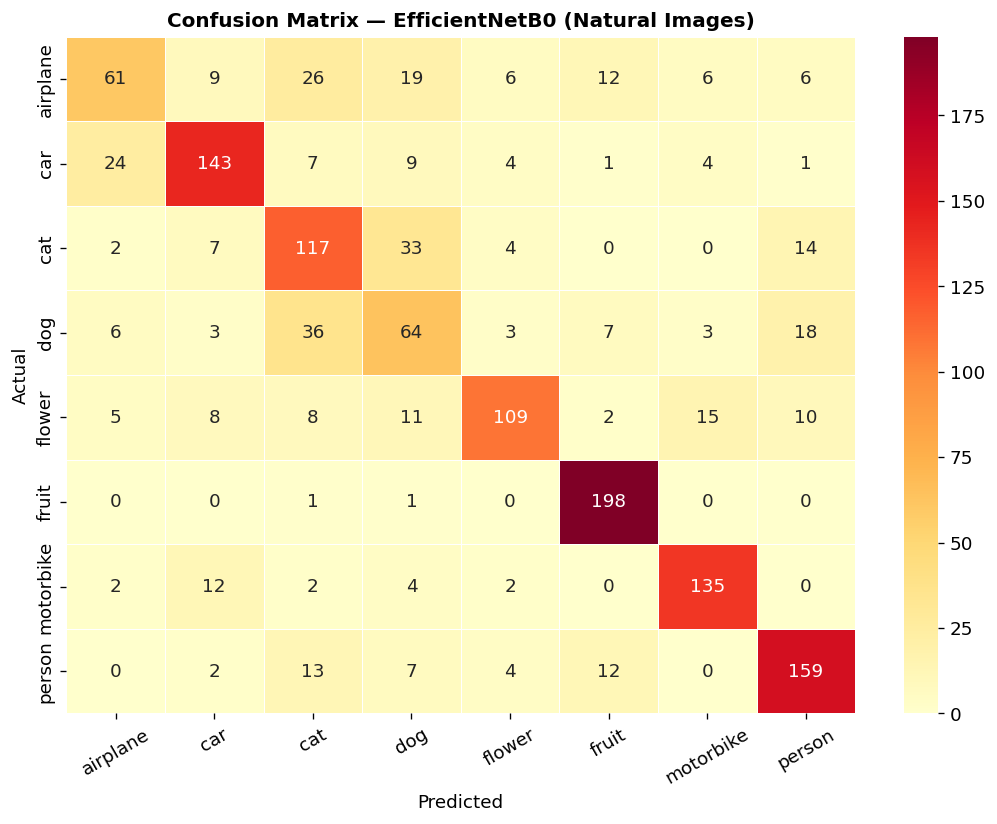

              precision    recall  f1-score   support

    airplane       0.61      0.42      0.50       145
         car       0.78      0.74      0.76       193
         cat       0.56      0.66      0.60       177
         dog       0.43      0.46      0.44       140
      flower       0.83      0.65      0.73       168
       fruit       0.85      0.99      0.92       200
   motorbike       0.83      0.86      0.84       157
      person       0.76      0.81      0.79       197

    accuracy                           0.72      1377
   macro avg       0.71      0.70      0.70      1377
weighted avg       0.72      0.72      0.71      1377



In [10]:
val_gen.reset()
y_pred_prob = model.predict(val_gen, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = val_gen.classes

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=classes, yticklabels=classes,
            linewidths=0.5, ax=ax)
ax.set_title('Confusion Matrix — EfficientNetB0 (Natural Images)')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/04_confusion_matrix.png', bbox_inches='tight')
plt.show()

print(classification_report(y_true, y_pred, target_names=classes))

## 🔍 4. Grad-CAM — Giải thích AI 'nhìn' vào đâu

In [11]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    """Tạo Grad-CAM heatmap từ ảnh đầu vào."""
    # Tách base_model để lấy conv output
    grad_model = tf.keras.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_out = conv_outputs[0]
    heatmap = conv_out @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), int(pred_index), predictions[0].numpy()

# Find last conv layer in base_model
last_conv_layer_name = None
for layer in reversed(model.layers):
    if 'efficientnetb0' in layer.name.lower():
        # Search inside the base_model layer
        for sub_layer in reversed(layer.layers):
            if 'conv' in sub_layer.name.lower():
                last_conv_layer_name = layer.name + '/' + sub_layer.name
                break
        break

# Simpler: build a dedicated grad-cam model
base_layer = model.get_layer('efficientnetb0')
last_conv = None
for layer in reversed(base_layer.layers):
    if hasattr(layer, 'kernel') and len(layer.output_shape) == 4:
        last_conv = layer
        break

print(f'Last conv layer: {last_conv.name}')

Last conv layer: top_conv


In [12]:
# Build dedicated GradCAM model
grad_cam_model = tf.keras.Model(
    inputs=base_layer.input,
    outputs=[last_conv.output, base_layer.output]
)

# Wrapper that uses the full pipeline
def compute_gradcam(img_array):
    with tf.GradientTape() as tape:
        conv_out, features = grad_cam_model(img_array)
        # Pass features through the head
        x = model.get_layer('global_average_pooling2d')(features)
        x = model.get_layer('batch_normalization')(x)
        x = model.get_layer('dense')(x)
        x = model.get_layer('dropout')(x)
        predictions = model.get_layer('dense_1')(x)
        pred_class = tf.argmax(predictions[0])
        class_score = predictions[:, pred_class]

    grads = tape.gradient(class_score, conv_out)
    pooled = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = conv_out[0] @ pooled[..., tf.newaxis]
    heatmap = tf.squeeze(tf.maximum(heatmap, 0))
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), int(pred_class), predictions[0].numpy()

print('✅ Grad-CAM model ready')

✅ Grad-CAM model ready


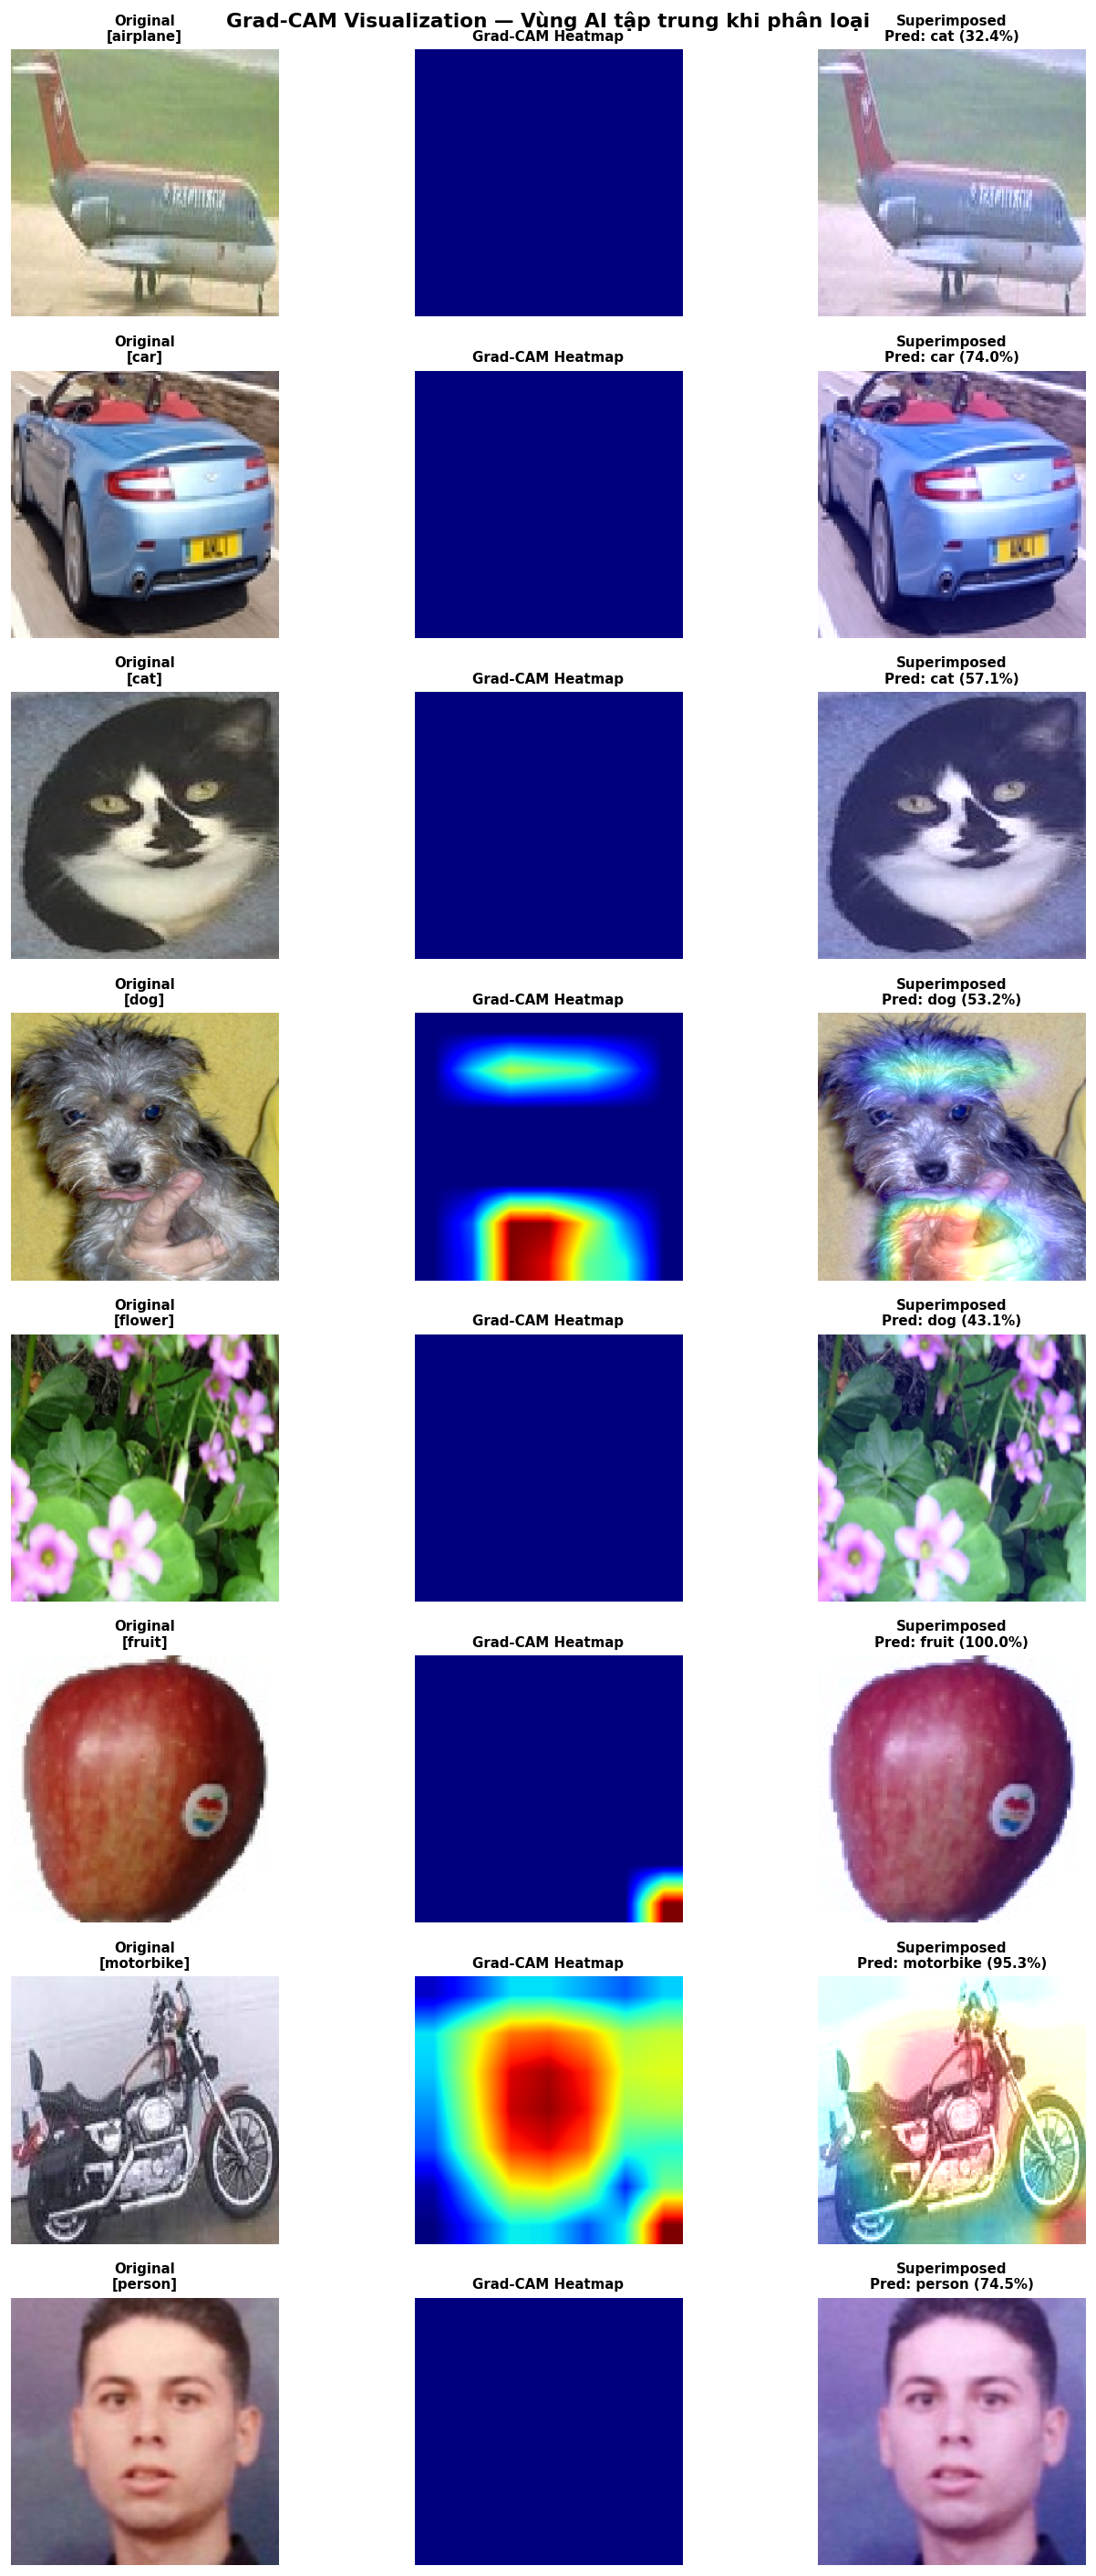

In [13]:
# Show Grad-CAM for one sample per class
fig, axes = plt.subplots(len(classes), 3, figsize=(12, len(classes)*3))

for r, cls in enumerate(classes):
    cls_dir = os.path.join(DATA_DIR, cls)
    sample_file = os.listdir(cls_dir)[0]
    sample_path = os.path.join(cls_dir, sample_file)

    orig_img = load_img(sample_path, target_size=IMG_SIZE)
    img_arr  = img_to_array(orig_img) / 255.0
    img_in   = np.expand_dims(img_arr, axis=0)

    try:
        heatmap, pred_idx, probs = compute_gradcam(tf.constant(img_in))

        # Resize heatmap
        heatmap_resized = cv2.resize(heatmap, IMG_SIZE)
        heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
        heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB) / 255.0
        superimposed = heatmap_color * 0.4 + img_arr
        superimposed = np.clip(superimposed, 0, 1)

        pred_label = classes[pred_idx]
        confidence = probs[pred_idx] * 100

        axes[r, 0].imshow(orig_img)
        axes[r, 0].set_title(f'Original\n[{cls}]', fontsize=9)
        axes[r, 0].axis('off')

        axes[r, 1].imshow(heatmap_resized, cmap='jet')
        axes[r, 1].set_title('Grad-CAM Heatmap', fontsize=9)
        axes[r, 1].axis('off')

        axes[r, 2].imshow(superimposed)
        axes[r, 2].set_title(f'Superimposed\nPred: {pred_label} ({confidence:.1f}%)', fontsize=9)
        axes[r, 2].axis('off')
    except Exception as e:
        for c in range(3):
            axes[r, c].axis('off')
        axes[r, 0].set_title(f'{cls}\nGradCAM Error', fontsize=9)

plt.suptitle('Grad-CAM Visualization — Vùng AI tập trung khi phân loại', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/05_gradcam_visualization.png', bbox_inches='tight')
plt.show()

In [14]:
best_val_acc = max(history.history['val_accuracy'])
with open(f'{SAVE_DIR}/report.txt', 'w') as f:
    f.write('Natural Images Classification — EfficientNetB0 + GradCAM\n' + '='*55 + '\n')
    f.write(f'Best Val Accuracy: {best_val_acc:.4f}\n')
    f.write(f'Total Params: {model.count_params():,}\n\n')
    f.write(classification_report(y_true, y_pred, target_names=classes))

print('✅ Natural Images EfficientNet + GradCAM Completed! Results saved to', SAVE_DIR)

✅ Natural Images EfficientNet + GradCAM Completed! Results saved to ../results/natural_images
